In [1]:
!pip install astropy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from astropy.io import fits
import csv

input_file  = r"hlsp_gswlc_galex-sdss-wise_multi_a1_multi_v1_cat.fits"
output_file = r"GSWLC-A1.csv"

# Open the FITS file
with fits.open(input_file) as hdul:
    # Data is usually in extension 1
    data = hdul[1].data
    columns = data.columns.names

    print(f"Found {len(data)} rows and {len(columns)} columns")
    print(f"Columns: {columns}")

    # Write to CSV
    with open(output_file, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(columns)  # header
        for row in data:
            writer.writerow([row[col] for col in columns])

print(f"Done! Saved to {output_file}")

Found 640659 rows and 26 columns
Columns: ['OBJID', 'GLXID', 'PLATE', 'MJD', 'FIBER_ID', 'RA', 'DECL', 'Z', 'REDCHISQ', 'LOGMSTAR', 'LOGMSTARERR', 'LOGSFRSED', 'LOGSFRSEDERR', 'AFUV', 'AFUVERR', 'AB', 'ABERR', 'AV', 'AVERR', 'FLAG_SED', 'UV_SURVEY', 'LOGSFRAW', 'FLAG_WISE', 'LOGSFRUW', 'FLAG_UNWISE', 'FLAG_MGS']
Done! Saved to GSWLC-A1.csv


In [8]:
import pandas as pd

# Load both GZ2 files (same folder as your notebook)
complete    = pd.read_csv("complete_gz2.csv")
photometric = pd.read_csv("photometric_gz2.csv")

# Inner join on dr7objid — unmatched rows are dropped
final = pd.merge(complete, photometric, on="dr7objid", how="inner")

# Save to same folder
final.to_csv("final_gz2.csv", index=False)

print(f"complete_gz2    : {len(complete)} rows")
print(f"photometric_gz2 : {len(photometric)} rows")
print(f"final_gz2       : {len(final)} rows (matched only)")

complete_gz2    : 243500 rows
photometric_gz2 : 243500 rows
final_gz2       : 243500 rows (matched only)


In [9]:
final.columns.tolist()

['specobjid_x',
 'dr8objid',
 'dr7objid',
 'ra_x',
 'dec_x',
 'rastring',
 'decstring',
 'sample',
 'gz2class',
 'total_classifications',
 'total_votes',
 't01_smooth_or_features_a01_smooth_count',
 't01_smooth_or_features_a01_smooth_weight',
 't01_smooth_or_features_a01_smooth_fraction',
 't01_smooth_or_features_a01_smooth_weighted_fraction',
 't01_smooth_or_features_a01_smooth_debiased',
 't01_smooth_or_features_a01_smooth_flag',
 't01_smooth_or_features_a02_features_or_disk_count',
 't01_smooth_or_features_a02_features_or_disk_weight',
 't01_smooth_or_features_a02_features_or_disk_fraction',
 't01_smooth_or_features_a02_features_or_disk_weighted_fraction',
 't01_smooth_or_features_a02_features_or_disk_debiased',
 't01_smooth_or_features_a02_features_or_disk_flag',
 't01_smooth_or_features_a03_star_or_artifact_count',
 't01_smooth_or_features_a03_star_or_artifact_weight',
 't01_smooth_or_features_a03_star_or_artifact_fraction',
 't01_smooth_or_features_a03_star_or_artifact_weighted_f

 ra_dec_tol_arcsec  z_tol  n_matches  pct_of_gz2
               0.5 0.0005     209410       86.00
               0.5 0.0010     209517       86.04
               0.5 0.0020     209535       86.05
               0.5 0.0050     209538       86.05
               0.5 0.0100     209541       86.05
               0.5 0.0200     209542       86.05
               1.0 0.0005     209611       86.08
               1.0 0.0010     209719       86.13
               1.0 0.0020     209737       86.13
               1.0 0.0050     209740       86.14
               1.0 0.0100     209743       86.14
               1.0 0.0200     209744       86.14
               1.5 0.0005     209638       86.09
               1.5 0.0010     209746       86.14
               1.5 0.0020     209766       86.15
               1.5 0.0050     209769       86.15
               1.5 0.0100     209772       86.15
               1.5 0.0200     209773       86.15
               2.0 0.0005     209660       86.10
               2.0 0

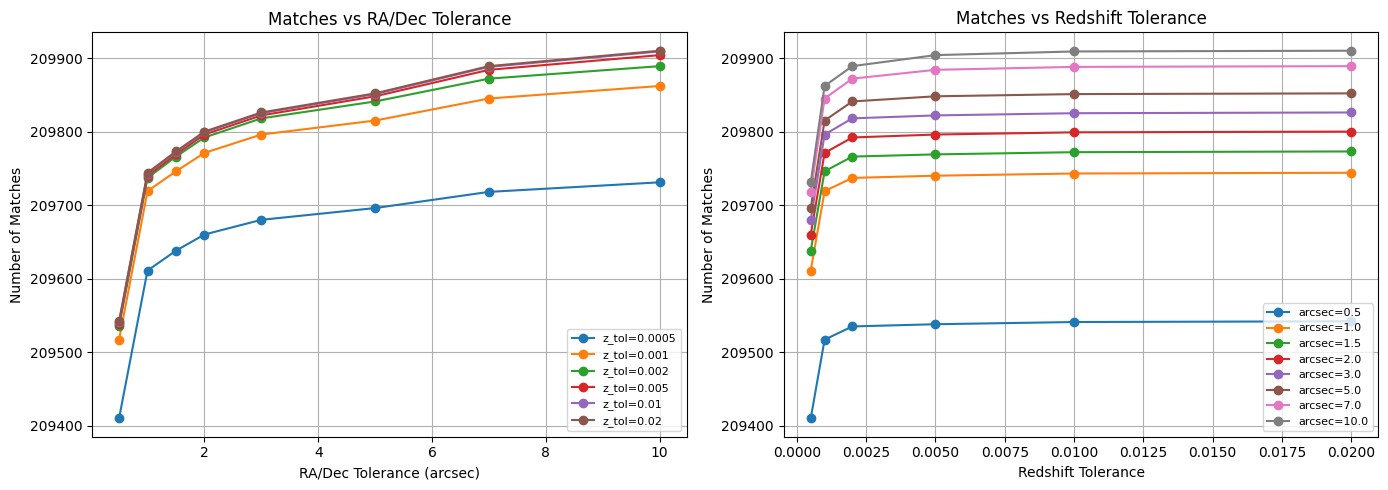


Plot saved as tolerance_sweep.png


In [12]:
import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt

# Load files
gz2   = pd.read_csv("final_gz2.csv")
gswlc = pd.read_csv("GSWLC-A1.csv")

# Build SkyCoord objects once
coords_gz2   = SkyCoord(ra=gz2["ra"].values    * u.degree,
                        dec=gz2["dec"].values   * u.degree)
coords_gswlc = SkyCoord(ra=gswlc["RA"].values  * u.degree,
                        dec=gswlc["DECL"].values * u.degree)

# Match RA/Dec once — just get separations
idx, sep, _ = coords_gz2.match_to_catalog_sky(coords_gswlc)
gz2_z   = gz2["spec_z"].values
gswlc_z = gswlc["Z"].values[idx]
z_diff  = np.abs(gz2_z - gswlc_z)
sep_arcsec = sep.arcsecond

# --- Sweep tolerances ---
ra_dec_tolerances  = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 7.0, 10.0]  # arcseconds
redshift_tolerances = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]

results = []

for rd_tol in ra_dec_tolerances:
    for z_tol in redshift_tolerances:
        n_matches = ((sep_arcsec <= rd_tol) & (z_diff <= z_tol)).sum()
        results.append({
            "ra_dec_tol_arcsec" : rd_tol,
            "z_tol"             : z_tol,
            "n_matches"         : n_matches,
            "pct_of_gz2"        : round(100 * n_matches / len(gz2), 2)
        })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# --- Plot 1: RA/Dec tolerance sweep (fixed z tolerance) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for z_tol in redshift_tolerances:
    subset = df_results[df_results["z_tol"] == z_tol]
    axes[0].plot(subset["ra_dec_tol_arcsec"], subset["n_matches"],
                 marker='o', label=f"z_tol={z_tol}")

axes[0].set_xlabel("RA/Dec Tolerance (arcsec)")
axes[0].set_ylabel("Number of Matches")
axes[0].set_title("Matches vs RA/Dec Tolerance")
axes[0].legend(fontsize=8)
axes[0].grid(True)

# --- Plot 2: Redshift tolerance sweep (fixed RA/Dec tolerance) ---
for rd_tol in ra_dec_tolerances:
    subset = df_results[df_results["ra_dec_tol_arcsec"] == rd_tol]
    axes[1].plot(subset["z_tol"], subset["n_matches"],
                 marker='o', label=f"arcsec={rd_tol}")

axes[1].set_xlabel("Redshift Tolerance")
axes[1].set_ylabel("Number of Matches")
axes[1].set_title("Matches vs Redshift Tolerance")
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.savefig("tolerance_sweep.png", dpi=150)
plt.show()

print("\nPlot saved as tolerance_sweep.png")

In [13]:
import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

gz2   = pd.read_csv("final_gz2.csv")
gswlc = pd.read_csv("GSWLC-A1.csv")

coords_gz2   = SkyCoord(ra=gz2["ra"].values    * u.degree,
                        dec=gz2["dec"].values   * u.degree)
coords_gswlc = SkyCoord(ra=gswlc["RA"].values  * u.degree,
                        dec=gswlc["DECL"].values * u.degree)

idx, sep, _ = coords_gz2.match_to_catalog_sky(coords_gswlc)

# Optimal tolerances from convergence analysis
ra_dec_tolerance  = 2.0    # arcseconds
redshift_tolerance = 0.002

ra_dec_match = sep.arcsecond <= ra_dec_tolerance
z_match      = np.abs(gz2["spec_z"].values - gswlc["Z"].values[idx]) <= redshift_tolerance
both_match   = ra_dec_match & z_match

gz2_matched   = gz2[both_match].reset_index(drop=True)
gswlc_matched = gswlc.iloc[idx[both_match]].reset_index(drop=True)
gswlc_matched = gswlc_matched.add_prefix("gswlc_")

final = pd.concat([gz2_matched, gswlc_matched], axis=1)
final.to_csv("final_crossmatched.csv", index=False)

print(f"Final matched rows: {len(final)}")

Final matched rows: 209792


In [14]:
final.columns.tolist()

['specobjid_x',
 'dr8objid',
 'dr7objid',
 'ra',
 'dec',
 'rastring',
 'decstring',
 'sample',
 'gz2class',
 'total_classifications',
 'total_votes',
 't01_smooth_or_features_a01_smooth_count',
 't01_smooth_or_features_a01_smooth_weight',
 't01_smooth_or_features_a01_smooth_fraction',
 't01_smooth_or_features_a01_smooth_weighted_fraction',
 't01_smooth_or_features_a01_smooth_debiased',
 't01_smooth_or_features_a01_smooth_flag',
 't01_smooth_or_features_a02_features_or_disk_count',
 't01_smooth_or_features_a02_features_or_disk_weight',
 't01_smooth_or_features_a02_features_or_disk_fraction',
 't01_smooth_or_features_a02_features_or_disk_weighted_fraction',
 't01_smooth_or_features_a02_features_or_disk_debiased',
 't01_smooth_or_features_a02_features_or_disk_flag',
 't01_smooth_or_features_a03_star_or_artifact_count',
 't01_smooth_or_features_a03_star_or_artifact_weight',
 't01_smooth_or_features_a03_star_or_artifact_fraction',
 't01_smooth_or_features_a03_star_or_artifact_weighted_fract